In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


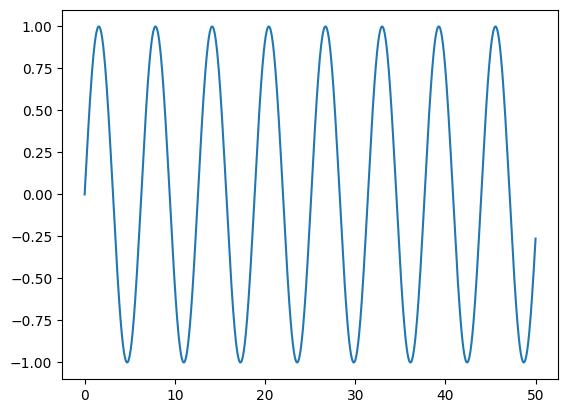

In [2]:
x = jnp.linspace(0, 50, 1000)
y = jnp.sin(x)
plt.plot(x, y)

In [3]:
%xmode minimal
x = jnp.arange(10)
y = x.at[0].apply(lambda x: x + 1)
y


Exception reporting mode: Minimal


Array([1, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [4]:
from jax.typing import ArrayLike
isinstance(jnp.array([1, 2, 3]), jax.Array)

True

In [ ]:
from jax import jit
def norm(X: jax.Array): # need to ensure shapes known at comile time for jit
    X = X - X.mean(axis=0)
    return X / X.std(axis=0)
jit_norm = jit(norm)

jax.jit(norm).lower(jnp.array([1, 2, 3])).cost_analysis()


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


{'flops': 31.0,
 'transcendentals': 1.0,
 'bytes accessed': 410.0,
 'utilization0{}': 23.0,
 'utilization1{}': 13.0,
 'bytes accessed0{}': 161.0,
 'bytes accessed1{}': 84.0,
 'bytes accessedout{}': 161.0,
 'utilization2{}': 1.0,
 'bytes accessed2{}': 4.0}

In [6]:
import numpy as np
np.random.seed(42)
x = jnp.array(np.random.rand(10000, 100))
np.allclose(norm(x), jit_norm(x), atol=1e-6)

True

In [7]:
# %timeit norm(x).block_until_ready()
# %timeit jit_norm(x).block_until_ready()

In [8]:
import time
@jax.jit
def f(x):
    return x * x + 2 * x + 1

x = jnp.ones((10000,10000))

# slow first run, fast subsequent runs
start = time.time()
f(x)        # compilation + run
print(time.time() - start)

start = time.time()
f(x)        # only run
print(time.time() - start)

0.09851980209350586
0.0007929801940917969


In [9]:
from jax import grad

def f(x):
    return x**2 + x

x = jnp.array(9.)
df_dx = grad(f)(x)
print(df_dx)

19.0


In [10]:
from jax import jacobian
from jax import grad

def sum_logistic(x):
  return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)

print("Derivative:", grad(sum_logistic)(x_small))

print("Jacobian:", jacobian(jnp.exp)(x_small))


Derivative: [0.25       0.19661197 0.10499357]
Jacobian: [[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [11]:
from jax import random
key = random.key(1701)
key, key2 = random.split(key)
mat = random.normal(key, (120, 100))
batched_x = random.normal(key2, (10, 100))
def apply_matrix(x):
    return jnp.dot(mat, x)

In [12]:
def naive_batch(v_batched): # v_batched is (10, 100) go through each row and apply matrix
    return jnp.stack([apply_matrix(v) for v in v_batched])
print("naive")
%timeit naive_batch(batched_x).block_until_ready()

naive
2.04 ms ± 225 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
from jax import vmap
@jax.jit
def manual_batch(v_batched):
    return jnp.dot(v_batched, mat.T)
print("manual")
%timeit manual_batch(batched_x).block_until_ready()

@jax.jit
def vmap_batch(v_batched):
    return vmap(apply_matrix)(v_batched)
print("vmap")
%timeit vmap_batch(batched_x).block_until_ready()

manual
42.2 μs ± 6.1 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
vmap
41.9 μs ± 4.32 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
key = random.key(69)
for i in range(3):
    new_key, subkey = random.split(key)
    del key

    val = random.normal(subkey)
    del subkey

    print("i: ", i, "val: ", val)
    key = new_key

i:  0 val:  1.0903112
i:  1 val:  -0.9403945
i:  2 val:  -0.5235094


In [ ]:
@jax.jit
def f(x):
    jax.debug.print("x: {}", x)
    return x

f(10)

x: 10


Array(10, dtype=int32, weak_type=True)

#### jax sharp bits
- use pure functions
- dont use iterators 
- dont use inplace updates
- use .at[] for updates (make copies of arrays with updates instead of modifying in place)
- dont get out of bounds errors. it will return 0 or last element instead of throwing an error, which can lead to silent bugs
- psuedo random number generation
- jax.jit, jax.grad, jax.vmap, jax.pmap require static shapes. shape cant depend on data
- use jax_debug_nans and jax_debug_infs to find nans and infs in your code. check jax debugging flags
- default precision is 32bits, can use 64 bits with jax.config.update("jax_enable_x64", True) but it will be slower
- 

In [ ]:
import jax.numpy as jnp
from jax import make_jaxpr

arr = jnp.arange(10)
print(jax.lax.fori_loop(0, 10, lambda i, x: x + arr[i], 0)) # 0 + arr[0] + arr[1] + ... + arr[9]
iterator = iter(range(10))
print(jax.lax.fori_loop(0, 10, lambda i, x: x + next(iterator), 0)) # unexpectedly returns 0 because next(iterator) is not traced by jax and is not pure, so it always returns the same value (the first value of the iterator)


45
0


In [ ]:
# how to jit methods of classes? use partial to jit the method and make the class method call
from functools import partial
class MyClass:
    def __init__(self, x):
        self.x = x

    def method(self, y):
        return _method(self.x, y)

@partial(jit, static_argnums=0)
def _method(x, y):
    return x + y

c = MyClass(10)
print(c.method(5))

15


In [42]:
# can use tricks for dyanamic shapes, but generally want to avoid them and use static shapes for best performance
@jit
def nansum(X):
    mask = ~jnp.isnan(X)
    # return X[mask].sum()
    return jnp.sum(jnp.where(mask, X, 0.0))

nansum(jnp.array([1., 2., jnp.nan, 4.]))

Array(7., dtype=float32)

In [48]:
def play(X):
    new = x +10
    new = new * 2
    return new

print(jax.make_jaxpr(play)(jnp.reshape(jnp.array([1, 2, 3, 4]), (2, 2))))

{ lambda a:f32[3]; b:i32[2,2]. let
    c:f32[3] = add a 10.0:f32[]
    d:f32[3] = mul c 2.0:f32[]
  in (d,) }


In [64]:
from functools import partial

@partial(jax.jit, static_argnames=['n']) # will error if not adding statuc argnames because n is used in a control flow statement and needs to be known at compile time, so we need to tell jax that n is statics
def gg(x, n):
  i = 0
  while i < n:
    i += 1
  return x + i

print(gg(10, 20))

30


In [87]:
import numpy as np
from jax.tree_util import tree_structure

def init_mlp_params(layer_widths):
  params = []
  for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
    params.append(
        dict(weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2/n_in),
             biases=np.ones(shape=(n_out,))
            )
    )
  return params

params = init_mlp_params([1, 128, 128, 1])
print(tree_structure(params))
jax.tree.map(lambda x: x.shape, params)

PyTreeDef([{'biases': *, 'weights': *}, {'biases': *, 'weights': *}, {'biases': *, 'weights': *}])


[{'biases': (128,), 'weights': (1, 128)},
 {'biases': (128,), 'weights': (128, 128)},
 {'biases': (1,), 'weights': (128, 1)}]

In [86]:
# Define the forward pass.
def forward(params, x):
  *hidden, last = params
  for layer in hidden:
    x = jax.nn.relu(x @ layer['weights'] + layer['biases'])
  return x @ last['weights'] + last['biases']

# Define the loss function.
def loss_fn(params, x, y):
  return jnp.mean((forward(params, x) - y) ** 2)

# Set the learning rate.
LEARNING_RATE = 0.0001

# Using the stochastic gradient descent, define the parameter update function.
# Apply `@jax.jit` for JIT compilation (speed).
@jax.jit
def update(params, x, y):
  # Calculate the gradients with `jax.grad`.
  grads = jax.grad(loss_fn)(params, x, y)
  # Note that `grads` is a pytree with the same structure as `params`.
  # `jax.grad` is one of many JAX functions that has
  # built-in support for pytrees.
  # This is useful - you can apply the SGD update using JAX pytree utilities.
  return jax.tree.map(
      lambda p, g: p - LEARNING_RATE * g, params, grads
  )

In [ ]:
a_tree = [jnp.zeros((2, 3)), jnp.zeros((3, 4))]

# Try to make another pytree with ones instead of zeros.
shapes = jax.tree.map(lambda x: x.shape, a_tree)
jax.tree.map(jnp.ones, shapes)


(2, 3)

In [ ]:
# Sharding
import jax.numpy as jnp
import jax
from jax.sharding import PartitionSpec, NamedSharding
jax.config.update('jax_num_cpu_devices', 8)
print(jax.devices())
mesh = jax.make_mesh((2, 3), ("x", "y"))
sharding = NamedSharding(mesh, PartitionSpec("x", "y"))
sharding

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


NamedSharding(mesh=Mesh('x': 2, 'y': 3, axis_types=(Explicit, Explicit)), spec=P('x', 'y'), memory_kind=device)

In [30]:
arr = jnp.arange(12).reshape(2, 6)
print(arr)
arr_sharded = jax.device_put(arr, sharding)
print(arr_sharded.sharding)
jax.debug.visualize_array_sharding(arr_sharded)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
NamedSharding(mesh=Mesh('x': 2, 'y': 3, axis_types=(Explicit, Explicit)), spec=P('x', 'y'), memory_kind=device)


                                                                           
                                                                           
          CPU 0                    CPU 1                    CPU 2          
                                                                           
                                                                           
                                                                           
                                                                           
                                                                           
          CPU 3                    CPU 4                    CPU 5          
                                                                           
                                                                           
                                                                           

In [23]:
@jax.jit
def f(x):
    return jnp.cos(x) + jnp.sin(x)

res = f(arr_sharded)
print(res.sharding == sharding)

True


In [31]:
@jax.jit()
def f_contract(x):
    return jnp.sum(x, axis=0)

res_contract = f_contract(arr_sharded)
print(res_contract)
jax.debug.visualize_array_sharding(res_contract)

[ 6  8 10 12 14 16]


 CPU 0,3  CPU 1,4  CPU 2,5 
                           

In [35]:
print(jax.typeof(arr))
print(jax.typeof(arr_sharded))

int32[2,6]
int32[2@x,6@y]


In [46]:
arr = jax.device_put(jnp.ones((2, 3)), jax.devices()[2])
print(arr.devices())

{CpuDevice(id=2)}


In [53]:
from jax import lax

operand = jnp.array([0.])
print(lax.cond(True, lambda x: x + 1, lambda x: x - 1, operand))

print(lax.while_loop(lambda x: x > 5, lambda x: x - 1, 10))


[1.]
5


## Flax

In [3]:
from flax import nnx
import optax
import jax
import jax.numpy as jnp

In [10]:
class Linear(nnx.Module):
    def __init__(self, din: int, dout: int, *, rngs: nnx.Rngs) -> None:
        self.din, self.dout = din, dout
        self.w = nnx.Param(rngs.params.uniform((din, dout)))
        self.b = nnx.Param(jnp.zeros((dout,)))

    def __call__(self, x):
        return x @ self.w + self.b

model = Linear(10, 5, rngs=nnx.Rngs(params=0))
y = model(jnp.ones((2, 10)))
print(y)
nnx.display(model)

[[5.604755 4.782773 3.924123 5.905212 6.038572]
 [5.604755 4.782773 3.924123 5.905212 6.038572]]
